Name : W. K. D. D. Senuruk  
## Fitting basics

Here, the need is to create a line which is suitable for the below data points

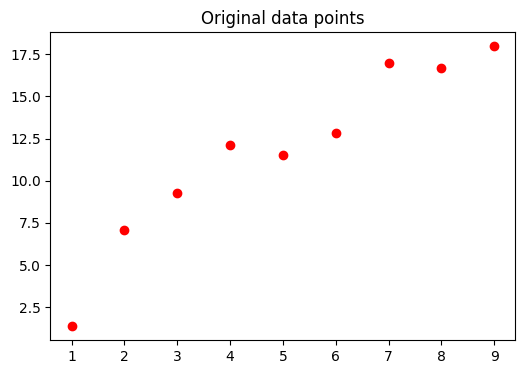

In [69]:
import matplotlib.pyplot as plt
import numpy as np

m = 2
c = 1
x = np.arange(1,10, 1)
n = 2.*np.random.randn(len(x))
o = np.zeros(x.shape)
# o[-1] = 20
y = m*x + c + n + o

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='red')
plt.title("Original data points")
plt.show()

#### Least-squares line fitting

Given a set of points (x_i, y_i), we want to fit a line:

$$
y = mx + b
$$

Our goal is to minimize the **sum of squared errors**:

$$
\text{Loss} = \sum_{i=1}^{n} (y_i - (mx_i + b))^2
$$

---

Let:

$$
\mathbf{A} =
\begin{bmatrix}
x_1 & 1 \\
x_2 & 1 \\
\vdots & \vdots \\
x_n & 1
\end{bmatrix},
\quad
\mathbf{x} =
\begin{bmatrix}
m \\
b
\end{bmatrix},
\quad
\mathbf{y} =
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
$$

Then the model becomes:

$$
\mathbf{A} \mathbf{x} \approx \mathbf{y}
$$

We find the best "m" and "b" by minimizing the squared error:

$$
\min_{\mathbf{x}} \|\mathbf{A}\mathbf{x} - \mathbf{y}\|_2^2
$$

The **least-squares solution** is given by:

$$
\mathbf{x} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{y}
$$


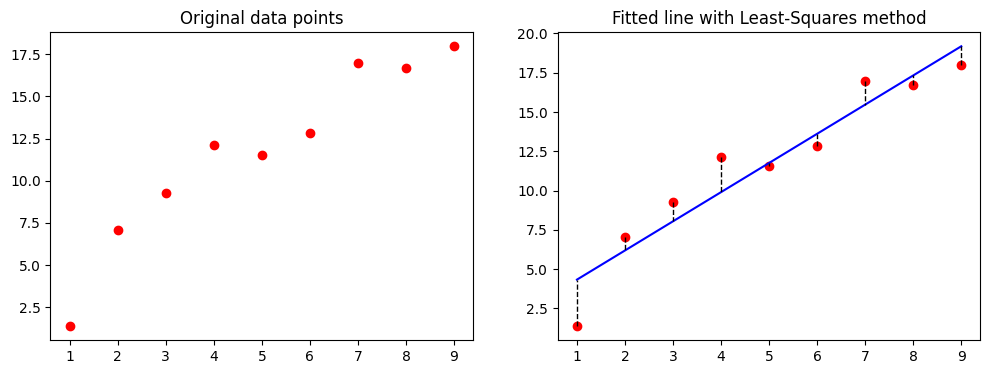

In [79]:
A = np.vstack([x, np.ones_like(x)]).T
y_ = np.reshape(y, (9, 1))

parameter_matrix = np.linalg.inv(A.T @ A) @ A.T @ y_

y_n = parameter_matrix[0][0] * x + parameter_matrix[1][0] * np.ones_like(x)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(x, y, color='red')
ax[0].set_title("Original data points")
ax[1].scatter(x, y, color='red')
ax[1].plot(x, y_n, color='blue')
for xi, yi, yi_pred in zip(x, y, y_n):
    ax[1].plot([xi, xi], [yi, yi_pred], 'k--', linewidth=1)
ax[1].set_title("Fitted line with Least-Squares method")
plt.show()

#### Total least-squares line fitting